# DATA 304 — Session 2: Text Normalization

This notebook mirrors the **Text Normalization** session and provides runnable examples.

## 0. Setup

In [1]:
# Core libs
import re, unicodedata, math, random, string
from collections import Counter

# Data
import pandas as pd
import numpy as np

# NLP 
# !pip -q install contractions spacy pyspellchecker
# !python -m spacy download en_core_web_sm
# !pip install nltk

## 1. Tiny sample dataset

In [2]:
raw_texts = [
    "They're RUNNING—résumé!  ",
    "Data, data; DATA.",
    "I can't, you won't.  ",
    "The leaves were falling and mice ran",
    "ML Engineer / Data Scientist II",
    "I love data 🧪📊!  ",
    "colur is my favrite",
    "résumé naïve café"
]

df = pd.DataFrame({
    "id": range(1, len(raw_texts)+1),
    "text": raw_texts,
})

df

,id,text
0,1,They're RUNNING—résumé!
1,2,"Data, data; DATA."
2,3,"I can't, you won't."
3,4,The leaves were falling and mice ran
4,5,ML Engineer / Data Scientist II
5,6,I love data 🧪📊!
6,7,colur is my favrite
7,8,résumé naïve café


## 2. Lowercasing

In [3]:
df['lower'] = df['text'].str.lower()
df[['id','text','lower']]

,id,text,lower
0,1,They're RUNNING—résumé!,they're running—résumé!
1,2,"Data, data; DATA.","data, data; data."
2,3,"I can't, you won't.","i can't, you won't."
3,4,The leaves were falling and mice ran,the leaves were falling and mice ran
4,5,ML Engineer / Data Scientist II,ml engineer / data scientist ii
5,6,I love data 🧪📊!,i love data 🧪📊!
6,7,colur is my favrite,colur is my favrite
7,8,résumé naïve café,résumé naïve café


## 3. Remove punctuation

In [4]:
df['no_punct'] = df['lower'].str.replace(r"[^\w\s]", " ", regex=True)
df[['id','lower','no_punct']]

,id,lower,no_punct
0,1,they're running—résumé!,they re running résumé
1,2,"data, data; data.",data data data
2,3,"i can't, you won't.",i can t you won t
3,4,the leaves were falling and mice ran,the leaves were falling and mice ran
4,5,ml engineer / data scientist ii,ml engineer data scientist ii
5,6,i love data 🧪📊!,i love data
6,7,colur is my favrite,colur is my favrite
7,8,résumé naïve café,résumé naïve café


## 4. Normalize whitespace

In [5]:
df['ws_norm'] = df['no_punct'].str.replace(r"\s+", " ", regex=True).str.strip()
df[['id','no_punct','ws_norm']]

,id,no_punct,ws_norm
0,1,they re running résumé,they re running résumé
1,2,data data data,data data data
2,3,i can t you won t,i can t you won t
3,4,the leaves were falling and mice ran,the leaves were falling and mice ran
4,5,ml engineer data scientist ii,ml engineer data scientist ii
5,6,i love data,i love data
6,7,colur is my favrite,colur is my favrite
7,8,résumé naïve café,résumé naïve café


## 5. Expand contractions

In [6]:
try:
    import contractions
except Exception as e:
    print("Install the 'contractions' package to run this cell: pip install contractions")
    raise

df['expanded'] = df['text'].apply(contractions.fix)
df[['id','text','expanded']]

,id,text,expanded
0,1,They're RUNNING—résumé!,They are RUNNING—résumé!
1,2,"Data, data; DATA.","Data, data; DATA."
2,3,"I can't, you won't.","I cannot, you will not."
3,4,The leaves were falling and mice ran,The leaves were falling and mice ran
4,5,ML Engineer / Data Scientist II,ML Engineer / Data Scientist II
5,6,I love data 🧪📊!,I love data 🧪📊!
6,7,colur is my favrite,colur is my favrite
7,8,résumé naïve café,résumé naïve café


## 6. Strip accents

In [7]:
import unicodedata
def strip_accents(s: str) -> str:
    return "".join(
        c for c in unicodedata.normalize("NFKD", s)
        if not unicodedata.combining(c)
    )

df['no_accents'] = df['expanded'].apply(strip_accents)
df[['id','expanded','no_accents']]

,id,expanded,no_accents
0,1,They are RUNNING—résumé!,They are RUNNING—resume!
1,2,"Data, data; DATA.","Data, data; DATA."
2,3,"I cannot, you will not.","I cannot, you will not."
3,4,The leaves were falling and mice ran,The leaves were falling and mice ran
4,5,ML Engineer / Data Scientist II,ML Engineer / Data Scientist II
5,6,I love data 🧪📊!,I love data 🧪📊!
6,7,colur is my favrite,colur is my favrite
7,8,résumé naïve café,resume naive cafe


## 7. Remove emojis

In [8]:
import re
emoji_pat = re.compile(r"[\U00010000-\U0010FFFF]")
df['no_emoji'] = df['no_accents'].str.replace(emoji_pat, "", regex=True)
df[['id','no_accents','no_emoji']]

,id,no_accents,no_emoji
0,1,They are RUNNING—resume!,They are RUNNING—resume!
1,2,"Data, data; DATA.","Data, data; DATA."
2,3,"I cannot, you will not.","I cannot, you will not."
3,4,The leaves were falling and mice ran,The leaves were falling and mice ran
4,5,ML Engineer / Data Scientist II,ML Engineer / Data Scientist II
5,6,I love data 🧪📊!,I love data !
6,7,colur is my favrite,colur is my favrite
7,8,resume naive cafe,resume naive cafe


## 8. Lemmatization (spaCy)

In [10]:
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    import subprocess, sys
    _ = subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=False)
    nlp = spacy.load("en_core_web_sm")

def lemmatize(s: str) -> str:
    doc = nlp(s)
    return " ".join(tok.lemma_ for tok in doc)

df['lemma'] = df['no_emoji'].apply(lemmatize)
df['lemma2'] = df['no_punct'].apply(lemmatize)
df[['id','no_emoji','lemma', 'no_punct','lemma2']]

,id,no_emoji,lemma,no_punct,lemma2
0,1,They are RUNNING—resume!,they be run — resume !,they re running résumé,they re run résumé
1,2,"Data, data; DATA.","Data , datum ; data .",data data data,datum datum datum
2,3,"I cannot, you will not.","I can not , you will not .",i can t you won t,I can t you win t
3,4,The leaves were falling and mice ran,the leaf be fall and mouse run,the leaves were falling and mice ran,the leaf be fall and mouse run
4,5,ML Engineer / Data Scientist II,ML Engineer / Data Scientist II,ml engineer data scientist ii,ml engineer data scientist ii
5,6,I love data !,I love datum !,i love data,I love datum
6,7,colur is my favrite,colur be my favrite,colur is my favrite,colur be my favrite
7,8,resume naive cafe,resume naive cafe,résumé naïve café,résumé naïve café


## 9. Stemming (NLTK PorterStemmer)

In [11]:
try:
    from nltk.stem import PorterStemmer
except Exception as e:
    print("Install NLTK to run this cell: pip install nltk")
    raise

ps = PorterStemmer()
df['stem'] = df['no_emoji'].str.lower().str.split().apply(lambda toks: " ".join(ps.stem(w) for w in toks))
df[['id','no_emoji','stem']]

,id,no_emoji,stem
0,1,They are RUNNING—resume!,they are running—resume!
1,2,"Data, data; DATA.","data, data; data."
2,3,"I cannot, you will not.","i cannot, you will not."
3,4,The leaves were falling and mice ran,the leav were fall and mice ran
4,5,ML Engineer / Data Scientist II,ml engin / data scientist ii
5,6,I love data !,i love data !
6,7,colur is my favrite,colur is my favrit
7,8,resume naive cafe,resum naiv cafe


## 10. Standardize spelling (pyspellchecker)

In [12]:
try:
    from spellchecker import SpellChecker
except Exception as e:
    print("Install pyspellchecker to run this cell: pip install pyspellchecker")
    raise

sp = SpellChecker(distance=1)
def correct_spelling(s: str) -> str:
    toks = s.split()
    corr = [sp.correction(w) or w for w in toks]
    return " ".join(corr)

df['spcorr'] = df['lemma'].apply(correct_spelling)
df[['id','lemma','spcorr']]

,id,lemma,spcorr
0,1,they be run — resume !,they be run i resume !
1,2,"Data , datum ; data .","Data , datum ; data ."
2,3,"I can not , you will not .","I can not , you will not ."
3,4,the leaf be fall and mouse run,the leaf be fall and mouse run
4,5,ML Engineer / Data Scientist II,my Engineer / Data Scientist i
5,6,I love datum !,I love datum !
6,7,colur be my favrite,color be my favorite
7,8,resume naive cafe,resume naive café


## 11. Pipeline: putting it together

In [13]:
import re
import contractions
def normalize_pipeline(text: str, nlp_model) -> str:
    t = text.lower()
    t = contractions.fix(t)
    t = re.sub(r"[^\w\s]", " ", t)
    t = strip_accents(t)
    t = re.sub(r"\s+", " ", t).strip()
    doc = nlp_model(t)
    t = " ".join(tok.lemma_ for tok in doc)
    return t

df['norm'] = df['text'].apply(lambda s: normalize_pipeline(s, nlp))
df[['id','text','norm']]

,id,text,norm
0,1,They're RUNNING—résumé!,they be run resume
1,2,"Data, data; DATA.",data datum datum
2,3,"I can't, you won't.",I can not you will not
3,4,The leaves were falling and mice ran,the leaf be fall and mouse run
4,5,ML Engineer / Data Scientist II,ml engineer data scientist ii
5,6,I love data 🧪📊!,I love datum
6,7,colur is my favrite,colur be my favrite
7,8,résumé naïve café,resume naive cafe


## 12. Measuring impact of normalization

In [14]:
import re
from collections import Counter

def tokenize(s: str):
    return re.findall(r"\w+", s.lower())

def charset_size(texts):
    return len(set("".join(texts)))

raw = df['text'].tolist()
clean = df['norm'].tolist()

# Unique docs
unique_before = len(set(raw))
unique_after  = len(set(clean))

# Frequencies
freq_before = Counter(tok for t in raw for tok in tokenize(t))
freq_after  = Counter(tok for t in clean for tok in tokenize(t))

# Charset
chars_before = charset_size(raw)
chars_after  = charset_size(clean)

# Effects
vocab_before = set(freq_before)
vocab_after  = set(freq_after)
vocab_shrink = (1 - len(vocab_after) / max(1, len(vocab_before)))
jaccard_vocab = len(vocab_before & vocab_after) / max(1, len(vocab_before | vocab_after))

summary = pd.Series({
    "unique_docs_before": unique_before,
    "unique_docs_after": unique_after,
    "tokens_before": sum(freq_before.values()),
    "tokens_after": sum(freq_after.values()),
    "vocab_size_before": len(vocab_before),
    "vocab_size_after": len(vocab_after),
    "vocab_shrink_fraction": round(vocab_shrink, 3),
    "jaccard_vocab_overlap": round(jaccard_vocab, 3),
    "charset_size_before": chars_before,
    "charset_size_after": chars_after,
    "charset_reduction": chars_before - chars_after,
}).to_frame("value")

summary

,value
unique_docs_before,8.000
unique_docs_after,8.000
tokens_before,35.000
tokens_after,35.000
vocab_size_before,28.000
vocab_size_after,26.000
vocab_shrink_fraction,0.071
jaccard_vocab_overlap,0.385
charset_size_before,43.000
charset_size_after,22.000


## 13. Visualize vocabulary change

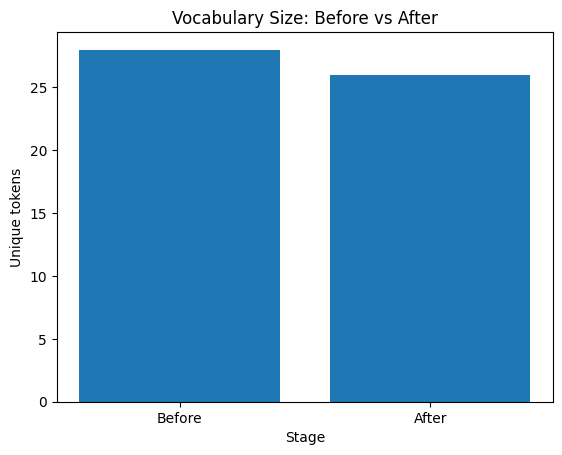

In [15]:
import matplotlib.pyplot as plt

labels = ["Before", "After"]
sizes = [summary.loc['vocab_size_before','value'], summary.loc['vocab_size_after','value']]
plt.figure()
plt.bar(labels, sizes)
plt.title("Vocabulary Size: Before vs After")
plt.xlabel("Stage")
plt.ylabel("Unique tokens")
plt.show()

## 14. Semantic normalization: dictionary-based mapping

In [16]:
roles = pd.Series([
    "Data Scientist II",
    "Senior Data Analyst",
    "ML Engineer",
    "machine learning engineer",
    "data analyst iii",
    "Director of Data Science"
], name="role_clean")

map_roles = {
    "data scientist": "ds",
    "data analyst": "da",
    "machine learning engineer": "ml"
}

def clean_role_simple(s: str) -> str:
    s2 = re.sub(r"[^a-zA-Z\s/+-]", " ", s.lower())
    s2 = re.sub(r"\s+", " ", s2).strip()
    return s2

role_norm = roles.apply(clean_role_simple)

# Exact mapping, then fallback
mapped = role_norm.replace(map_roles).where(lambda x: x.isin(map_roles.values()), other="other")
pd.DataFrame({"raw": roles, "cleaned": role_norm, "role_std": mapped})

,raw,cleaned,role_std
0,Data Scientist II,data scientist ii,other
1,Senior Data Analyst,senior data analyst,other
2,ML Engineer,ml engineer,other
3,machine learning engineer,machine learning engineer,ml
4,data analyst iii,data analyst iii,other
5,Director of Data Science,director of data science,other


## 15. Regex-based semantic mapping

In [17]:
patterns = {
    r'^data\s+scientist(\b.*)?$': 'ds',
    r'^data\s+analyst(\b.*)?$': 'da',
    r'^(ml|m/?l|machine\s*learning)\s+engineer(\b.*)?$': 'ml',
}
role_std_regex = role_norm.replace(patterns, regex=True).fillna("other")


display(pd.DataFrame({
    "raw": roles,
    "cleaned": role_norm,
    "role_std": role_std_regex
}))

,raw,cleaned,role_std
0,Data Scientist II,data scientist ii,ds
1,Senior Data Analyst,senior data analyst,senior data analyst
2,ML Engineer,ml engineer,ml
3,machine learning engineer,machine learning engineer,ml
4,data analyst iii,data analyst iii,da
5,Director of Data Science,director of data science,director of data science


## 16. Multi-field cleaning workflow demo

In [18]:
demo = pd.DataFrame({
    "address": ["123 Main St, Knoxville, TN 37996", "456 2nd Ave, Nashville, TN 37209"],
    "city_ref": ["knoxville", "nashville"]
})

profile = demo.describe(include='object')
display(profile)

demo['city'] = demo['address'].str.extract(r'(,[A-Za-z\s]+),').iloc[:,0].str.strip()
demo['zip']  = demo['address'].str.extract(r'(\d{5})').iloc[:,0]
demo['city_norm'] = demo['city'].str.lower().str.replace(r"\s+", " ", regex=True).str.replace(",", "", regex=False).str.strip()

ref = pd.DataFrame({"city_norm": ["knoxville", "nashville"], "valid_city": [True, True]})
demo = demo.merge(ref, on="city_norm", how="left", indicator=True)
demo

/tmp/ipykernel_2260/1859574969.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  profile = demo.describe(include='object')


,address,city_ref
count,2,2
unique,2,2
top,"123 Main St, Knoxville, TN 37996",knoxville
freq,1,1


,address,city_ref,city,zip,city_norm,valid_city,_merge
0,"123 Main St, Knoxville, TN 37996",knoxville,", Knoxville",37996,knoxville,True,both
1,"456 2nd Ave, Nashville, TN 37209",nashville,", Nashville",37209,nashville,True,both


## 17. Performance tips and quick profiling

In [19]:
big = pd.DataFrame({"txt": np.random.choice(df['text'], size=20000, replace=True)})

def vec_clean(s: pd.Series) -> pd.Series:
    return (s.str.lower()
              .str.replace(r"[^\w\s]", " ", regex=True)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())

def py_apply_clean(s: pd.Series) -> pd.Series:
    def f(x):
        t = x.lower()
        t = re.sub(r"[^\w\s]", " ", t)
        t = re.sub(r"\s+", " ", t).strip()
        return t
    return s.apply(f)

print("Vectorized:")
get_ipython().run_line_magic('timeit', 'vec_clean(big[\'txt\'])')
print("Python apply:")
get_ipython().run_line_magic('timeit', 'py_apply_clean(big[\'txt\'])')

big.memory_usage(deep=True)

Vectorized:
56.3 ms ± 14.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Python apply:
70.5 ms ± 6.81 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Index        132
txt      1760933
dtype: int64